In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import dirichlet, beta
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

NOTA THRESHOLD T(k) EXAMPLES
k=1 (uncontested), Vmax=100%: T = 1.550 (155%)
k=2, Vmax=55%: T = 0.900 (90%)
k=3, Vmax=36%: T = 0.643 (64%)
k=4, Vmax=30%: T = 0.550 (55%)

T(k) VALUES FOR DIFFERENT k AND LEADING SHARES

T(k) as decimal:
Vmax/Vtotal   0.25   0.30   0.35   0.40   0.45   0.50
k                                                    
1            0.800  0.850  0.900  0.950  1.000  1.050
2            0.600  0.650  0.700  0.750  0.800  0.850
3            0.533  0.583  0.633  0.683  0.733  0.783
4            0.500  0.550  0.600  0.650  0.700  0.750
5            0.480  0.530  0.580  0.630  0.680  0.730
6            0.467  0.517  0.567  0.617  0.667  0.717


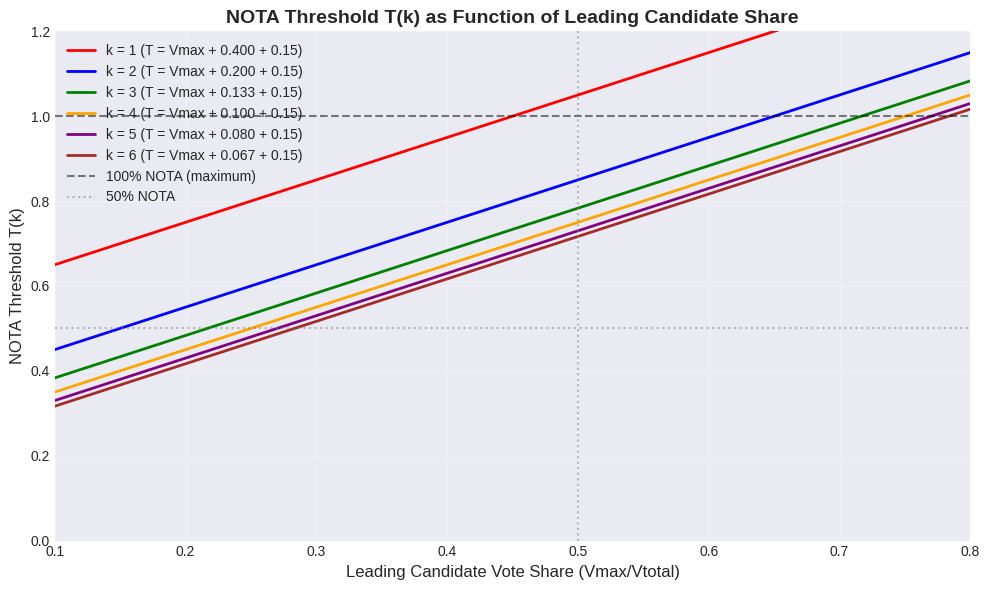

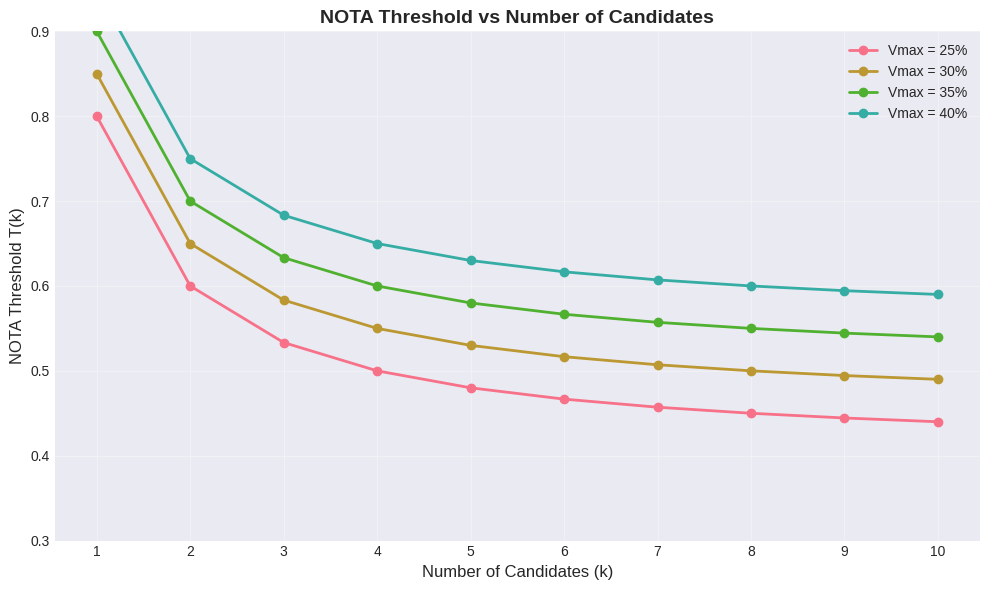

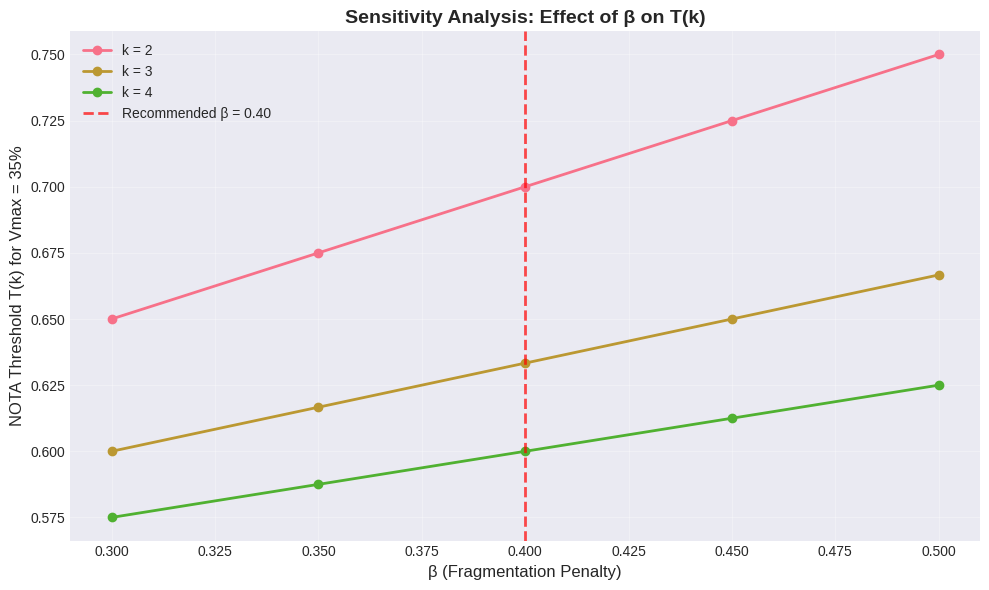


SENSITIVITY TO β (Vmax = 35%)
 k β=0.3 β=0.35 β=0.4 β=0.45 β=0.5
 2 65.0%  67.5% 70.0%  72.5% 75.0%
 3 60.0%  61.7% 63.3%  65.0% 66.7%
 4 57.5%  58.8% 60.0%  61.2% 62.5%


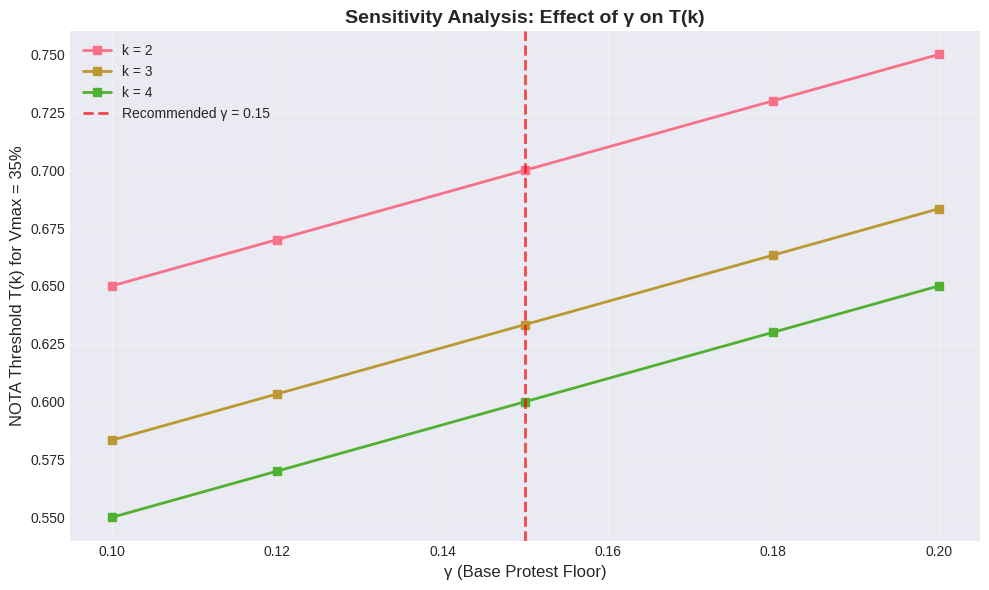


SENSITIVITY TO γ (Vmax = 35%)
 k γ=0.1 γ=0.12 γ=0.15 γ=0.18 γ=0.2
 2 65.0%  67.0%  70.0%  73.0% 75.0%
 3 58.3%  60.3%  63.3%  66.3% 68.3%
 4 55.0%  57.0%  60.0%  63.0% 65.0%


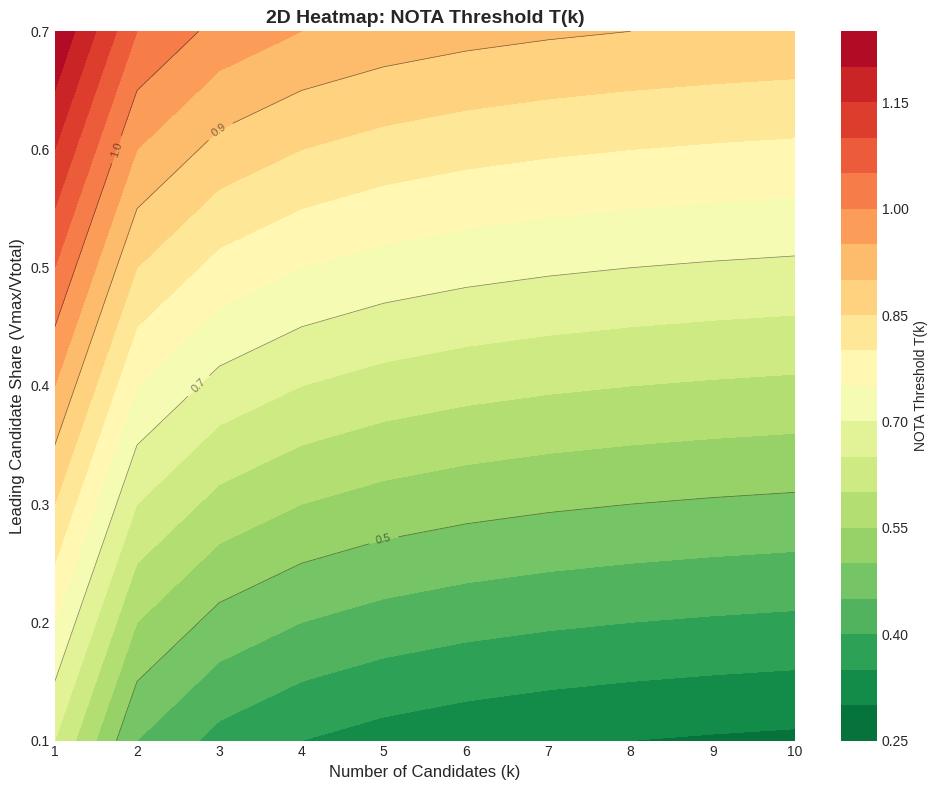


NISER GYMKHANA ELECTIONS 2026 - NOTA THRESHOLDS BY POST

Post                                    k              T(k) Formula   Example (Vmax=35%)
-------------------------------------------------------------------------------------
President                               1       Vmax + 0.400 + 0.15                90.0%
Gen Sec, Cultural Affairs               1       Vmax + 0.400 + 0.15                90.0%
Gen Sec, Campus Affairs                 4       Vmax + 0.100 + 0.15                60.0%
Gen Sec, Sports Affairs                 3       Vmax + 0.133 + 0.15                63.3%
Joint Sec, Cultural Affairs             2       Vmax + 0.200 + 0.15                70.0%
Joint Sec, Campus Affairs               1       Vmax + 0.400 + 0.15                90.0%
Joint Sec, Sports Affairs               2       Vmax + 0.200 + 0.15                70.0%

KEY INSIGHTS

• Uncontested posts (k=1): T(1) = 155% → NOTA defeat IMPOSSIBLE
• Joint Secretary posts (k=2): T(2) = Vmax + 0.35 → NOTA needs ~7

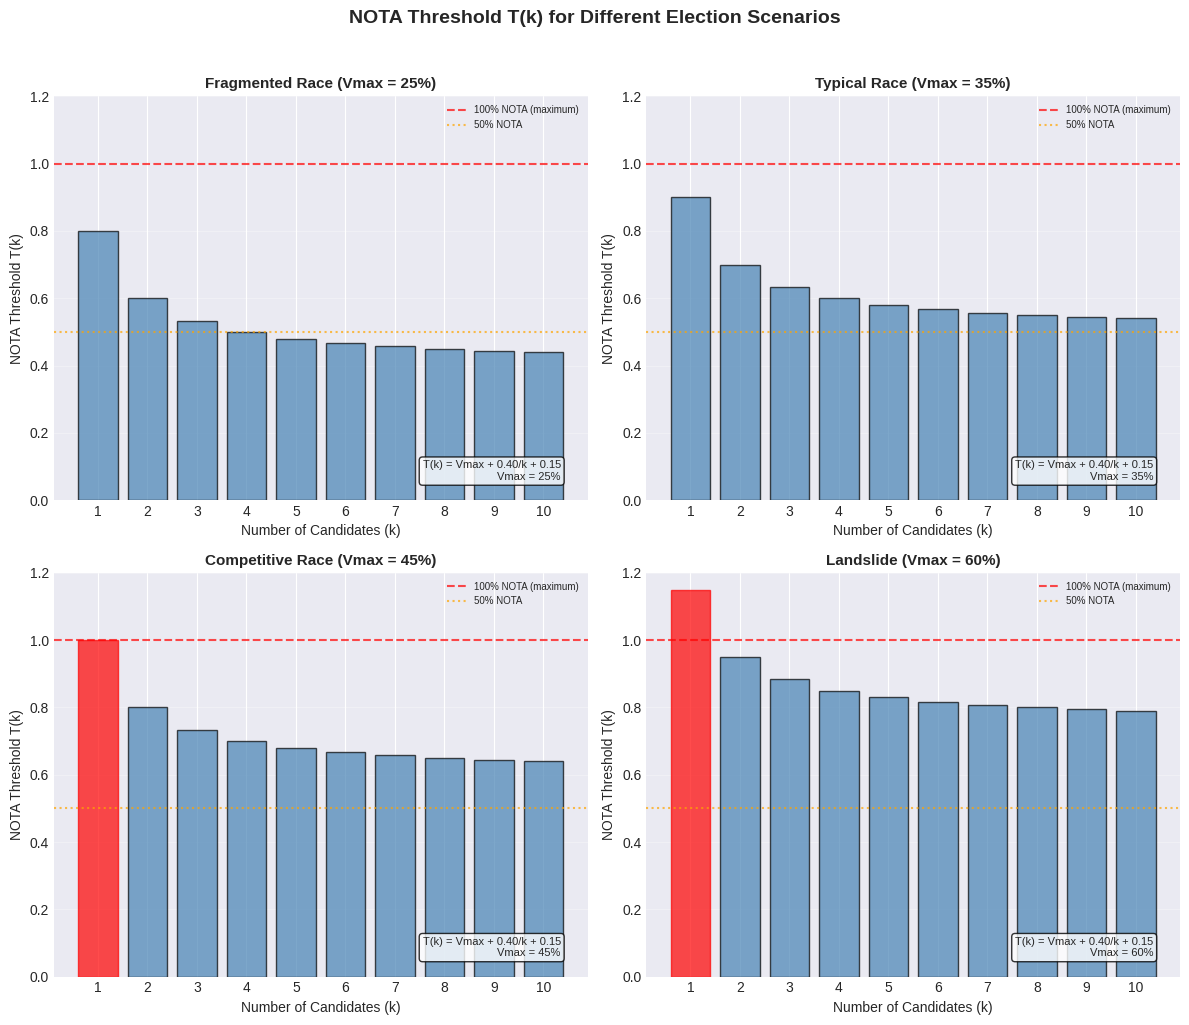


SUMMARY: EFFECT OF HYPERPARAMETERS ON T(k) (Vmax = 35%)

T(k) for k=2,3,4 with varying β and γ:
 k   β    γ  T(k)
 2 0.3 0.10 60.0%
 2 0.3 0.15 65.0%
 2 0.3 0.20 70.0%
 2 0.4 0.10 65.0%
 2 0.4 0.15 70.0%
 2 0.4 0.20 75.0%
 2 0.5 0.10 70.0%
 2 0.5 0.15 75.0%
 2 0.5 0.20 80.0%
 3 0.3 0.10 55.0%
 3 0.3 0.15 60.0%
 3 0.3 0.20 65.0%
 3 0.4 0.10 58.3%
 3 0.4 0.15 63.3%
 3 0.4 0.20 68.3%
 3 0.5 0.10 61.7%
 3 0.5 0.15 66.7%
 3 0.5 0.20 71.7%
 4 0.3 0.10 52.5%
 4 0.3 0.15 57.5%
 4 0.3 0.20 62.5%
 4 0.4 0.10 55.0%
 4 0.4 0.15 60.0%
 4 0.4 0.20 65.0%
 4 0.5 0.10 57.5%
 4 0.5 0.15 62.5%
 4 0.5 0.20 67.5%

RECOMMENDED DEFAULT PARAMETERS
β = 0.40  (Fragmentation penalty)
γ = 0.15  (Base protest floor)

Final formula: T(k) = Vmax/Vtotal + 0.40/k + 0.15

✅ All plots saved:
  - Tk_vs_Vmax.png
  - Tk_vs_k.png
  - beta_sensitivity.png
  - gamma_sensitivity.png
  - Tk_heatmap.png
  - Tk_scenarios.png


In [7]:
# %% [markdown]
# # NOTA Threshold T(k) Analysis for NISER Gymkhana Elections 2026
#
# This script computes and visualizes T(k) for different candidate counts and hyperparameter sensitivity.

# %% [code]
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# %% [markdown]
# ## 1. Define the NOTA Threshold Function

# %% [code]
def T(k, Vmax_ratio, beta=0.40, gamma=0.15):
    """
    Calculate NOTA threshold T(k)

    Parameters:
    -----------
    k : int
        Number of candidates
    Vmax_ratio : float
        Leading candidate vote share (Vmax/Vtotal)
    beta : float
        Fragmentation penalty (default 0.40)
    gamma : float
        Base protest floor (default 0.15)

    Returns:
    --------
    float : NOTA threshold as decimal
    """
    return Vmax_ratio + beta/k + gamma

# Test the function
print("="*60)
print("NOTA THRESHOLD T(k) EXAMPLES")
print("="*60)
print(f"k=1 (uncontested), Vmax=100%: T = {T(1, 1.0):.3f} ({T(1, 1.0)*100:.0f}%)")
print(f"k=2, Vmax=55%: T = {T(2, 0.55):.3f} ({T(2, 0.55)*100:.0f}%)")
print(f"k=3, Vmax=36%: T = {T(3, 0.36):.3f} ({T(3, 0.36)*100:.0f}%)")
print(f"k=4, Vmax=30%: T = {T(4, 0.30):.3f} ({T(4, 0.30)*100:.0f}%)")

# %% [markdown]
# ## 2. T(k) for Different Candidate Counts (Fixed Vmax)

# %% [code]
# Parameters
Vmax_values = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
k_values = [1, 2, 3, 4, 5, 6]

# Create DataFrame
data = []
for k in k_values:
    for Vmax in Vmax_values:
        data.append({
            'k': k,
            'Vmax/Vtotal': Vmax,
            'T(k)': T(k, Vmax),
            'T(k)%': f"{T(k, Vmax)*100:.1f}%"
        })

df = pd.DataFrame(data)

# Pivot for better display
pivot_df = df.pivot(index='k', columns='Vmax/Vtotal', values='T(k)')

print("\n" + "="*60)
print("T(k) VALUES FOR DIFFERENT k AND LEADING SHARES")
print("="*60)
print("\nT(k) as decimal:")
print(pivot_df.round(3))

# %% [markdown]
# ## 3. Visualization: T(k) vs Leading Share for Different k

# %% [code]
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
Vmax_range = np.linspace(0.1, 0.8, 100)

for idx, k in enumerate(k_values):
    T_values = [T(k, v) for v in Vmax_range]
    ax.plot(Vmax_range, T_values, linewidth=2, color=colors[idx],
            label=f'k = {k} (T = Vmax + {0.40/k:.3f} + 0.15)')

# Add reference lines
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='100% NOTA (maximum)')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='50% NOTA')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Leading Candidate Vote Share (Vmax/Vtotal)', fontsize=12)
ax.set_ylabel('NOTA Threshold T(k)', fontsize=12)
ax.set_title('NOTA Threshold T(k) as Function of Leading Candidate Share', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.1, 0.8)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig('Tk_vs_Vmax.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 4. Visualization: T(k) vs Number of Candidates (Fixed Vmax)

# %% [code]
fig, ax = plt.subplots(figsize=(10, 6))

Vmax_fixed = [0.25, 0.30, 0.35, 0.40]
k_range = range(1, 11)

for Vmax in Vmax_fixed:
    T_values = [T(k, Vmax) for k in k_range]
    ax.plot(k_range, T_values, marker='o', linewidth=2,
            label=f'Vmax = {Vmax:.0%}')

ax.set_xlabel('Number of Candidates (k)', fontsize=12)
ax.set_ylabel('NOTA Threshold T(k)', fontsize=12)
ax.set_title('NOTA Threshold vs Number of Candidates', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 11))
ax.set_ylim(0.3, 0.9)

plt.tight_layout()
plt.savefig('Tk_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 5. Sensitivity to Hyperparameter β (Fragmentation Penalty)

# %% [code]
fig, ax = plt.subplots(figsize=(10, 6))

beta_values = [0.30, 0.35, 0.40, 0.45, 0.50]
k_fixed = [2, 3, 4]
Vmax_fixed = 0.35

for k in k_fixed:
    T_values = [T(k, Vmax_fixed, beta=b) for b in beta_values]
    ax.plot(beta_values, T_values, marker='o', linewidth=2,
            label=f'k = {k}')

# Mark recommended beta
ax.axvline(x=0.40, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Recommended β = 0.40')

ax.set_xlabel('β (Fragmentation Penalty)', fontsize=12)
ax.set_ylabel(f'NOTA Threshold T(k) for Vmax = {Vmax_fixed:.0%}', fontsize=12)
ax.set_title('Sensitivity Analysis: Effect of β on T(k)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('beta_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Print beta sensitivity table
print("\n" + "="*60)
print("SENSITIVITY TO β (Vmax = 35%)")
print("="*60)
beta_table = []
for k in k_fixed:
    row = {'k': k}
    for b in beta_values:
        row[f'β={b}'] = f"{T(k, 0.35, beta=b)*100:.1f}%"
    beta_table.append(row)

beta_df = pd.DataFrame(beta_table)
print(beta_df.to_string(index=False))

# %% [markdown]
# ## 6. Sensitivity to Hyperparameter γ (Base Protest Floor)

# %% [code]
fig, ax = plt.subplots(figsize=(10, 6))

gamma_values = [0.10, 0.12, 0.15, 0.18, 0.20]
k_fixed = [2, 3, 4]
Vmax_fixed = 0.35

for k in k_fixed:
    T_values = [T(k, Vmax_fixed, gamma=g) for g in gamma_values]
    ax.plot(gamma_values, T_values, marker='s', linewidth=2,
            label=f'k = {k}')

# Mark recommended gamma
ax.axvline(x=0.15, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Recommended γ = 0.15')

ax.set_xlabel('γ (Base Protest Floor)', fontsize=12)
ax.set_ylabel(f'NOTA Threshold T(k) for Vmax = {Vmax_fixed:.0%}', fontsize=12)
ax.set_title('Sensitivity Analysis: Effect of γ on T(k)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Print gamma sensitivity table
print("\n" + "="*60)
print("SENSITIVITY TO γ (Vmax = 35%)")
print("="*60)
gamma_table = []
for k in k_fixed:
    row = {'k': k}
    for g in gamma_values:
        row[f'γ={g}'] = f"{T(k, 0.35, gamma=g)*100:.1f}%"
    gamma_table.append(row)

gamma_df = pd.DataFrame(gamma_table)
print(gamma_df.to_string(index=False))

# %% [markdown]
# ## 7. 2D Heatmap: T(k) for All Combinations

# %% [code]
fig, ax = plt.subplots(figsize=(10, 8))

# Create grid
k_grid = np.arange(1, 11, 1)
Vmax_grid = np.linspace(0.1, 0.7, 13)
K_mesh, V_mesh = np.meshgrid(k_grid, Vmax_grid)
T_mesh = T(K_mesh, V_mesh)

# Plot heatmap
im = ax.contourf(K_mesh, V_mesh, T_mesh, levels=20, cmap='RdYlGn_r')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('NOTA Threshold T(k)', fontsize=10)

# Add contour lines
contour = ax.contour(K_mesh, V_mesh, T_mesh, levels=[0.5, 0.7, 0.9, 1.0],
                     colors='black', linewidths=0.5, alpha=0.5)
ax.clabel(contour, inline=True, fontsize=8)

ax.set_xlabel('Number of Candidates (k)', fontsize=12)
ax.set_ylabel('Leading Candidate Share (Vmax/Vtotal)', fontsize=12)
ax.set_title('2D Heatmap: NOTA Threshold T(k)', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('Tk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 8. NISER-Specific Table (Actual Posts)

# %% [code]
print("\n" + "="*70)
print("NISER GYMKHANA ELECTIONS 2026 - NOTA THRESHOLDS BY POST")
print("="*70)

niser_posts = [
    {'post': 'President', 'k': 1, 'note': 'Elected unopposed'},
    {'post': 'Gen Sec, Cultural Affairs', 'k': 1, 'note': 'Elected unopposed'},
    {'post': 'Gen Sec, Campus Affairs', 'k': 4, 'note': 'Contested (4 candidates)'},
    {'post': 'Gen Sec, Sports Affairs', 'k': 3, 'note': 'Contested (3 candidates)'},
    {'post': 'Joint Sec, Cultural Affairs', 'k': 2, 'note': 'Contested (2 candidates)'},
    {'post': 'Joint Sec, Campus Affairs', 'k': 1, 'note': 'Elected unopposed'},
    {'post': 'Joint Sec, Sports Affairs', 'k': 2, 'note': 'Contested (2 candidates)'}
]

print("\n{:<35} {:>5} {:>25} {:>20}".format('Post', 'k', 'T(k) Formula', 'Example (Vmax=35%)'))
print("-" * 85)

for p in niser_posts:
    k = p['k']
    formula = f"Vmax + {0.40/k:.3f} + 0.15"
    example = f"{T(k, 0.35)*100:.1f}%"
    print("{:<35} {:>5} {:>25} {:>20}".format(p['post'], k, formula, example))

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print("""
• Uncontested posts (k=1): T(1) = 155% → NOTA defeat IMPOSSIBLE
• Joint Secretary posts (k=2): T(2) = Vmax + 0.35 → NOTA needs ~70% for typical race
• Sports Affairs (k=3): T(3) = Vmax + 0.283 → NOTA needs ~63% for typical race
• Campus Affairs (k=4): T(4) = Vmax + 0.25 → NOTA needs ~60% for typical race
""")

# %% [markdown]
# ## 9. Interactive-Like Slider Visualization (Static Version)

# %% [code]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Different scenarios
scenarios = [
    {'title': 'Fragmented Race (Vmax = 25%)', 'Vmax': 0.25},
    {'title': 'Typical Race (Vmax = 35%)', 'Vmax': 0.35},
    {'title': 'Competitive Race (Vmax = 45%)', 'Vmax': 0.45},
    {'title': 'Landslide (Vmax = 60%)', 'Vmax': 0.60}
]

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    Vmax = scenario['Vmax']
    k_range = range(1, 11)
    T_values = [T(k, Vmax) for k in k_range]

    # Bar plot
    bars = ax.bar(k_range, T_values, color='steelblue', alpha=0.7, edgecolor='black')

    # Color bars that exceed 100% red
    for bar, val in zip(bars, T_values):
        if val >= 1.0:
            bar.set_color('red')
            bar.set_alpha(0.7)

    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='100% NOTA (maximum)')
    ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.7, label='50% NOTA')

    ax.set_xlabel('Number of Candidates (k)', fontsize=10)
    ax.set_ylabel('NOTA Threshold T(k)', fontsize=10)
    ax.set_title(f"{scenario['title']}", fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

    # Add text annotation
    ax.text(0.95, 0.05, f'T(k) = Vmax + 0.40/k + 0.15\nVmax = {Vmax:.0%}',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('NOTA Threshold T(k) for Different Election Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Tk_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 10. Summary Table of Hyperparameter Sensitivity

# %% [code]
print("\n" + "="*70)
print("SUMMARY: EFFECT OF HYPERPARAMETERS ON T(k) (Vmax = 35%)")
print("="*70)

# Create comprehensive sensitivity table
sensitivity_data = []
for k in [2, 3, 4]:
    for beta in [0.30, 0.40, 0.50]:
        for gamma in [0.10, 0.15, 0.20]:
            T_val = T(k, 0.35, beta=beta, gamma=gamma)
            sensitivity_data.append({
                'k': k,
                'β': beta,
                'γ': gamma,
                'T(k)': f"{T_val:.1%}"
            })

sensitivity_df = pd.DataFrame(sensitivity_data)
print("\nT(k) for k=2,3,4 with varying β and γ:")
print(sensitivity_df.to_string(index=False))

print("\n" + "="*70)
print("RECOMMENDED DEFAULT PARAMETERS")
print("="*70)
print("β = 0.40  (Fragmentation penalty)")
print("γ = 0.15  (Base protest floor)")
print("\nFinal formula: T(k) = Vmax/Vtotal + 0.40/k + 0.15")

# Save all figures
print("\nAll plots saved:")
print("  - Tk_vs_Vmax.png")
print("  - Tk_vs_k.png")
print("  - beta_sensitivity.png")
print("  - gamma_sensitivity.png")
print("  - Tk_heatmap.png")
print("  - Tk_scenarios.png")